# Dynamic causal representation learning — organized project

This notebook contains all experiment and training settings, calls the project functions, and displays diagnostics.

- **Stage 0:** train and freeze the observation compressor $C(Y,I)$.
- **Stage 1, Block 1:** learn the causal representation and move graph/mechanism particles.
- **Stage 1, Block 2:** train the conditional graph ($G^{lag}$ and $G^{inst}$) & mechanism ($H$) flow using the frozen context encoder.

In [1]:
from dataclasses import dataclass, field
from typing import Optional, Tuple

from IPython.display import display
import torch

from utils import set_seed
from sim import simulate_experiment_data
from particles import GraphSpace
from fm import FMMetadata
from train import run_stage0, run_stage1
from diagnostics import (
    block1_summary,
    latent_correlation_table,
    plot_stage0_trace,
    plot_training_trace,
    evaluate_test_posterior,
    posterior_metric_table,
    plot_graph_distribution,
    plot_representative_graph_samples,
    h_rmse_to_truth,
    plot_h_diagnostics,
)


## 1. Experiment and training settings


In [2]:
def best_available_device() -> str:
    return "cuda" if torch.cuda.is_available() else "cpu"

@dataclass
class ExperimentConfig:
    # Reproducibility / runtime
    SEED: int = 13
    DEVICE: str = field(default_factory=best_available_device)

    # Data / simulation
    N: int = 300
    TRAIN_L: int = 90
    TEST_L: int = 90
    N_TEST: int = 80
    P: int = 40
    A: int = 3
    K_DATA: int = 2
    K_FIT: int = 2
    VAL_FRAC: float = 0.25

    # Observation model
    OBS_NONLINEAR_STRENGTH: float = 0.10
    OBS_NOISE_SD: float = 0.03

    # Stage 0: observation compressor
    CONTEXT_TOKENS: int = 4
    CONTEXT_WIDTH: int = 64
    CONTEXT_LAYERS: int = 2
    CONTEXT_HEADS: int = 4
    CONTEXT_LR: float = 1e-3
    CONTEXT_STEPS: int = 1000
    CONTEXT_BATCH: int = 32
    CONTEXT_MIN_LENGTH: Optional[int] = None

    # Stage 1, Block 1: representation and particles
    MAX_OUTER: int = 500
    LR_REP: float = 1e-4
    LR_MILESTONES: Tuple[int, ...] = (10, 20, 28)
    LR_GAMMA: float = 0.25
    RECON_SIGMA: float = 0.20
    BETA_STRUCT: float = 0.20
    ENCODER_RESIDUAL_STRENGTH: float = 0.02
    REP_UPDATES_PER_OUTER: int = 3
    REP_BATCH_TRAJ: int = 64
    USE_INTERVENTION_WARMSTART: bool = True

    RIDGE: float = 1e-3
    LAMBDA_LAG_SCORE: float = 0.001
    LAMBDA_INST_SCORE: float = 0.001

    RESP_TEMP: float = 1.0
    PI_ALPHA: float = 1.0
    RESP_FLOOR: float = 1e-4
    MIN_EFFECTIVE_N: float = 12.0
    DEAD_PATIENCE: int = 3

    GRAPH_MOVES_PER_OUTER: int = 3
    TAU_GRAPH: float = 5e-4
    ETA_H: float = 0.65
    TAU_H: float = 0.60
    TAU_LOGVAR: float = 0.02

    # Stage 1, Block 2: conditional graph/H FM
    FM_HIDDEN: int = 64
    FM_LR: float = 1e-4
    FM_UPDATES_PER_OUTER: int = 5
    FM_BATCH: int = 100
    FM_SIM_REPS_PER_COMPONENT_INTERVENTION: int = 50
    FM_SIM_LENGTHS: Tuple[int, ...] = field(default_factory=tuple)

    FM_GRAPH_EPS: float = 0.02
    FM_LAMBDA_LAG: float = 1.0
    FM_LAMBDA_INST: float = 1.0
    FM_LAMBDA_H: float = 1.0

    H_COEF_SCALE: float = 1.0
    H_LOGVAR_SCALE: float = 3.0
    H_INT_MEAN_SCALE: float = 2.0

    FM_GEN_STEPS: int = 100
    FM_ETA: float = 0.0
    FM_SAMPLES_PER_TEST: int = 3

    PARTICLE_PLOT_BURNIN: int = 20

    def __post_init__(self) -> None:
        if self.CONTEXT_MIN_LENGTH is None:
            self.CONTEXT_MIN_LENGTH = max(20, self.TRAIN_L // 2)
        if not self.FM_SIM_LENGTHS:
            self.FM_SIM_LENGTHS = tuple(sorted({
                max(20, self.TRAIN_L // 2),
                self.TRAIN_L,
                int(round(1.5 * self.TRAIN_L)),
            }))
        if self.K_FIT < self.K_DATA:
            raise ValueError("K_FIT must be >= K_DATA")

    @property
    def CONTEXT_DIM(self) -> int:
        return self.CONTEXT_TOKENS * self.CONTEXT_WIDTH

    @property
    def D(self) -> int:
        return self.A

    @property
    def L(self) -> int:
        return self.TRAIN_L


cfg = ExperimentConfig()


## 2. Simulation


In [3]:
device = set_seed(cfg)

data = simulate_experiment_data(cfg, device)
graph_space = GraphSpace.build(cfg)
fm_metadata = FMMetadata.build(cfg, graph_space)

print("device:", device, "seed:", cfg.SEED)
print("train Y:", data.Y_np.shape, "test Y:", data.Y_test_np.shape)
print("train/validation trajectories:", len(data.train_idx), len(data.val_idx))
print("graph pairs:", len(graph_space.graph_pairs))
print("true graph-pair indices:", graph_space.true_pair_indices(data))
print("context dimension:", cfg.CONTEXT_DIM)
print("H dimension:", fm_metadata.h_dim)
print("FM eta:", cfg.FM_ETA)


device: cuda seed: 13
train Y: (300, 90, 40) test Y: (80, 90, 40)
train/validation trajectories: 225 75
graph pairs: 1600
true graph-pair indices: [1310, 294]
context dimension: 256
H dimension: 33
FM eta: 0.0


## 3. Stage 0 — train and freeze \(C(Y,I)\)


/home/ganchao/miniconda3/envs/vfm/lib/python3.9/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


context step=0001 | reconstruction=1.15879
context step=0100 | reconstruction=0.05431
context step=0200 | reconstruction=0.05980
context step=0300 | reconstruction=0.05403
context step=0400 | reconstruction=0.05480
context step=0500 | reconstruction=0.05288
context step=0600 | reconstruction=0.05323
context step=0700 | reconstruction=0.05449
context step=0800 | reconstruction=0.05259
context step=0900 | reconstruction=0.05357
context step=1000 | reconstruction=0.05548
Stage-0 validation reconstruction MSE: 0.06388410180807114
frozen context dimension: 256


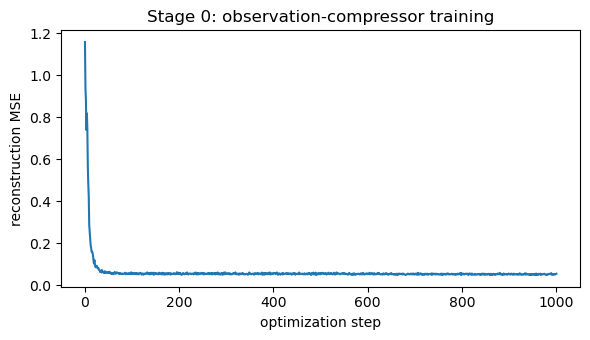

In [4]:
stage0 = run_stage0(cfg, data, verbose=True)
print("Stage-0 validation reconstruction MSE:", stage0["validation_mse"])
print("frozen context dimension:", cfg.CONTEXT_DIM)
plot_stage0_trace(stage0)


## 4. Stage 1 — Block 1 particles and Block 2 FM


In [5]:
result = run_stage1(
    cfg,
    data,
    graph_space,
    fm_metadata,
    stage0["context_net"],
    verbose=True,
)


outer=01 | ARI=1.000 | pi=[0.594 0.406] | d=[[8, 4], [8, 4]] | MH accepts=1 | FM=3.228
outer=05 | ARI=1.000 | pi=[0.543 0.457] | d=[[5, 5], [6, 4]] | MH accepts=1 | FM=3.890
outer=10 | ARI=1.000 | pi=[0.547 0.453] | d=[[4, 6], [8, 2]] | MH accepts=0 | FM=3.748
outer=15 | ARI=1.000 | pi=[0.549 0.451] | d=[[3, 7], [7, 3]] | MH accepts=2 | FM=3.526
outer=20 | ARI=1.000 | pi=[0.548 0.452] | d=[[3, 7], [10, 0]] | MH accepts=0 | FM=3.213
outer=25 | ARI=1.000 | pi=[0.548 0.452] | d=[[4, 8], [10, 0]] | MH accepts=1 | FM=2.628
outer=30 | ARI=1.000 | pi=[0.547 0.453] | d=[[4, 8], [10, 0]] | MH accepts=0 | FM=1.945
outer=35 | ARI=1.000 | pi=[0.548 0.452] | d=[[0, 10], [9, 1]] | MH accepts=0 | FM=2.404
outer=40 | ARI=1.000 | pi=[0.549 0.451] | d=[[0, 10], [9, 1]] | MH accepts=1 | FM=1.851
outer=45 | ARI=1.000 | pi=[0.548 0.452] | d=[[0, 10], [9, 1]] | MH accepts=2 | FM=1.543
outer=50 | ARI=1.000 | pi=[0.548 0.452] | d=[[0, 10], [10, 0]] | MH accepts=0 | FM=1.407
outer=55 | ARI=1.000 | pi=[0.548 0.

## 5. Block-1 diagnostics


,component,pi,effective N,graph pair index,distance to truth 1,distance to truth 2
0,1,0.547086,164.220038,1310,0,10
1,2,0.452914,135.779962,299,11,1


learned-vs-true latent correlation:


,true z1,true z2,true z3
learned z1,0.999730,0.403003,-0.190754
learned z2,0.407186,0.999880,-0.725044
learned z3,-0.185476,-0.701106,0.999004


target-coordinate absolute correlations: [1.    1.    0.999]


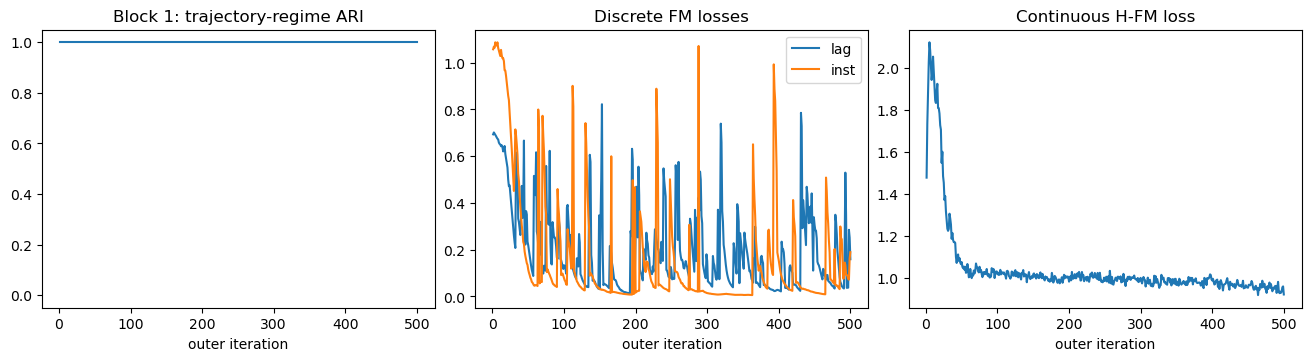

In [6]:
display(block1_summary(result, cfg, data, graph_space))

latent_corr = latent_correlation_table(result, cfg, data)
print("learned-vs-true latent correlation:")
display(latent_corr)
print("target-coordinate absolute correlations:",
      abs(latent_corr.to_numpy().diagonal()).round(3))

plot_training_trace(result)


## 6. Conditional graph/H posterior on the independent test set


In [7]:
posterior = evaluate_test_posterior(
    result,
    cfg,
    data,
    graph_space,
    fm_metadata,
)
display(posterior_metric_table(posterior, cfg))
print("standardized H RMSE to the true test regime:",
      h_rmse_to_truth(posterior, cfg, data, fm_metadata))


,metric,value
0,test recording length,90.000000
1,DeFoG eta,0.000000
2,instantaneous DAG validity,1.000000
3,exact lag graph,0.466667
4,exact instantaneous graph,0.804167
5,exact joint graph pair,0.341667


standardized H RMSE to the true test regime: 1.1750472784042358


## 7. Graph-distribution diagnostics


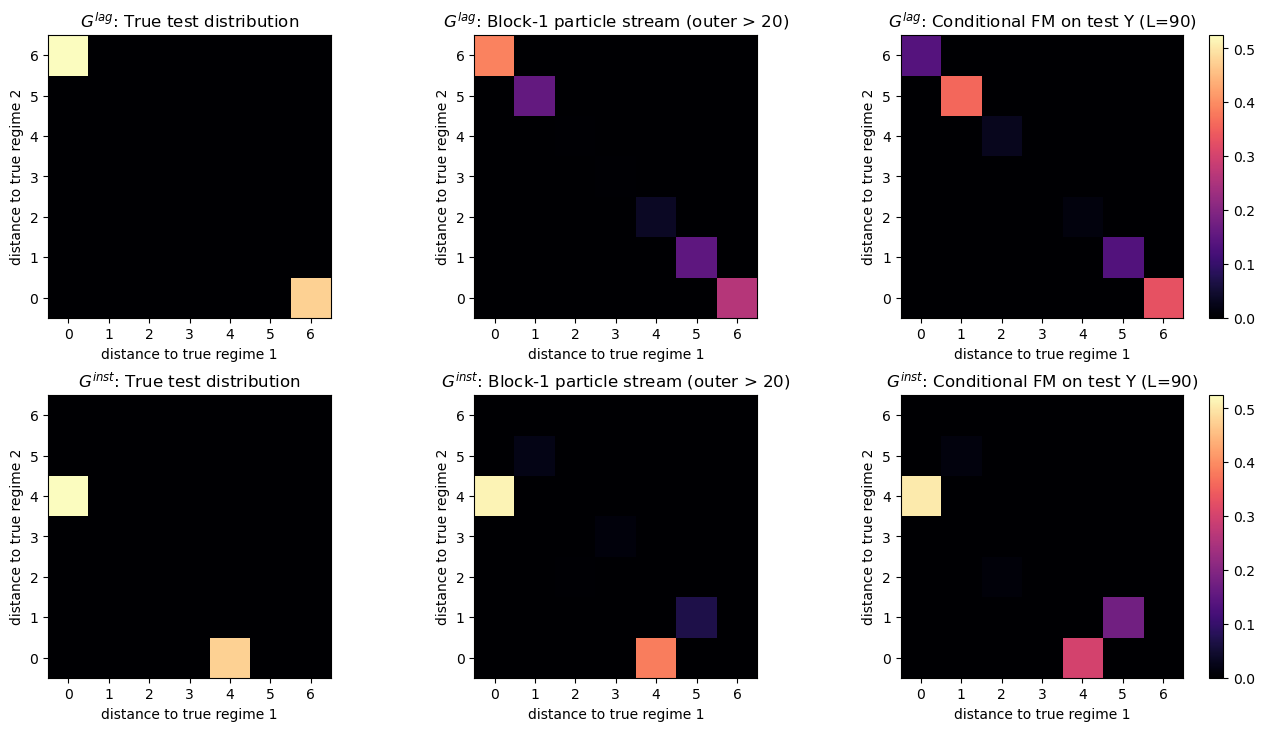

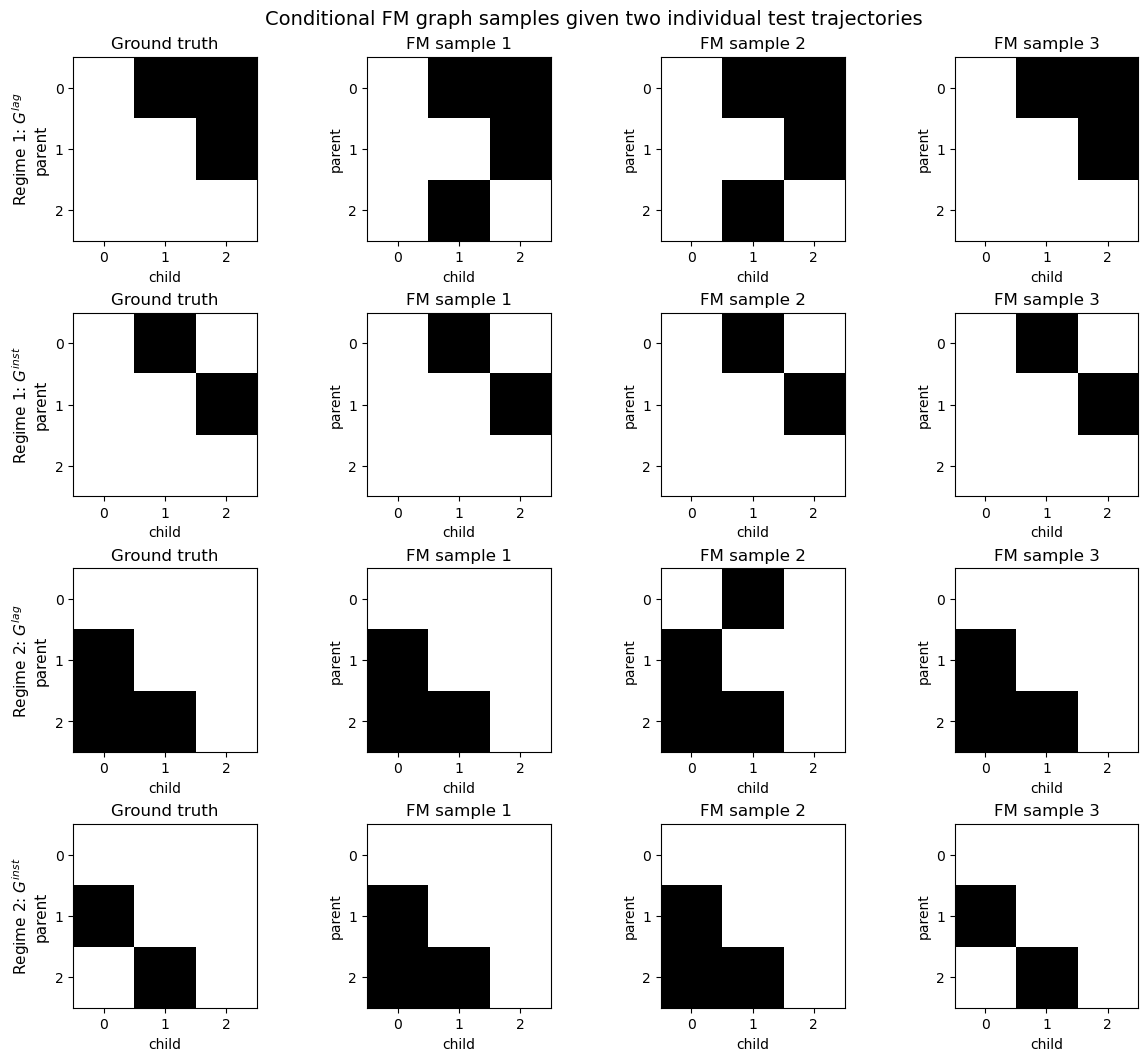

representative test indices: [2, 0]
regime 1: index=2, I=[0, 0, 1], length=90
regime 2: index=0, I=[0, 0, 0], length=90


In [8]:
plot_graph_distribution(result, posterior, cfg, data, graph_space)

chosen_test_indices = plot_representative_graph_samples(
    result,
    posterior,
    cfg,
    data,
    graph_space,
    fm_metadata,
    n_samples=3,
)

print("representative test indices:", chosen_test_indices)
for regime, test_index in enumerate(chosen_test_indices):
    print(
        f"regime {regime + 1}: index={test_index}, "
        f"I={data.I_test_np[test_index].astype(int).tolist()}, "
        f"length={len(data.Y_test_np[test_index])}"
    )


## 8. Conditional \(H\) diagnostic with the true graph fixed


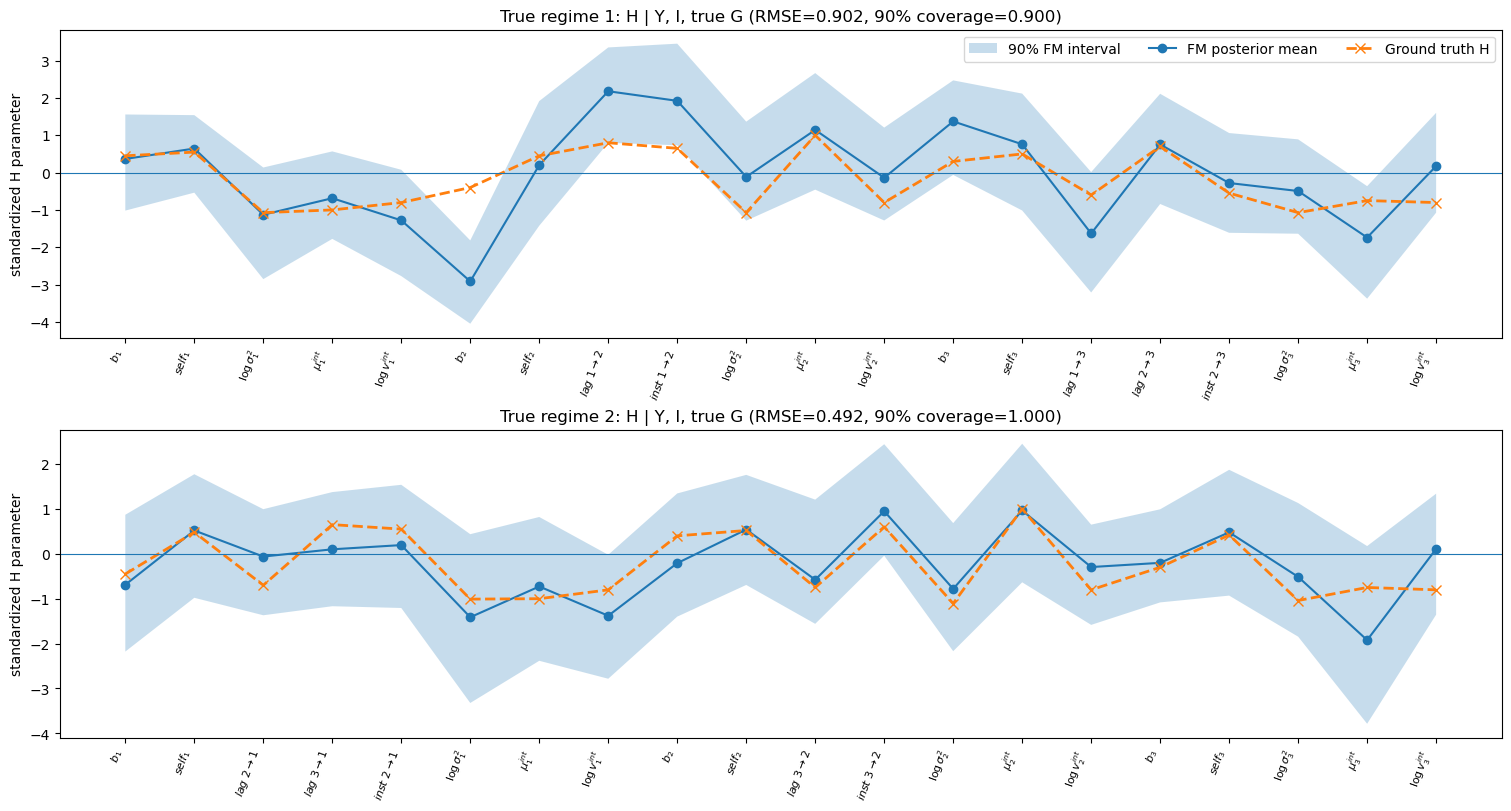

,true regime,test trajectory index,I,active H dimensions,posterior mean RMSE,90% interval coverage
0,1,2,"[0, 0, 1]",20,0.901881,0.9
1,2,0,"[0, 0, 0]",20,0.492452,1.0


In [9]:
h_summary = plot_h_diagnostics(
    result,
    posterior,
    chosen_test_indices,
    cfg,
    data,
    graph_space,
    fm_metadata,
    n_samples=30,
)
display(h_summary)
